## 1. Imports

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## 2. Config

In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "almaty_noise_training.csv"
ARTIFACTS_DIR = ROOT / "artifacts"

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET = "noise_class"

## 3. Load Data

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
display(df.head())
display(df[TARGET].value_counts().rename_axis(TARGET).reset_index(name="rows"))

Rows: 10,000
Columns: 11


,latitude,longitude,recorded_at,day_of_week,day_of_week_num,is_weekend,month,hour,period,noise_class,noise_level_dba
0,43.238371,76.914357,2026-02-25T15:14:34+05:00,Wednesday,2,0,2,15,daytime,others,52.82
1,43.237236,76.924403,2026-03-22T09:41:58+05:00,Sunday,6,1,3,9,morning,transport,68.87
2,43.233136,76.975432,2026-04-19T18:41:44+05:00,Sunday,6,1,4,18,evening,human,60.49
3,43.259635,76.943863,2026-02-23T11:52:08+05:00,Monday,0,0,2,11,daytime,transport,65.48
4,43.239064,76.927923,2026-01-30T08:02:45+05:00,Friday,4,0,1,8,morning,transport,83.41


,noise_class,rows
0,transport,3000
1,human,3000
2,others,1400
3,building_noise,1000
4,alert,900
5,animals,700


## 4. Class Distribution

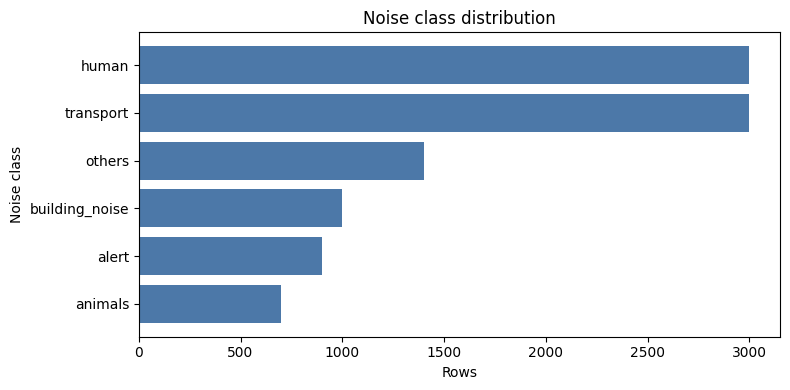

In [4]:
class_counts = df[TARGET].value_counts().sort_values(ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(class_counts.index, class_counts.values, color="#4C78A8")
plt.title("Noise class distribution")
plt.xlabel("Rows")
plt.ylabel("Noise class")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [5]:
df = df.copy()
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week_num"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week_num"] / 7)

numeric_features = [
    "latitude",
    "longitude",
    "month",
    "hour",
    "day_of_week_num",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

categorical_features = ["period"]
feature_columns = numeric_features + categorical_features
X = df[feature_columns]
y = df[TARGET]

## 6. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Train rows: 8,000
Test rows: 2,000


## 7. Preprocessing And Model

In [7]:
def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", make_encoder(), categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=160,
                max_depth=18,
                min_samples_leaf=3,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

## 8. Train

In [8]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)

## 9. Metrics

In [9]:
metrics = {
    "accuracy": round(float(accuracy_score(y_test, predictions)), 4),
    "f1_macro": round(float(f1_score(y_test, predictions, average="macro")), 4),
    "f1_weighted": round(float(f1_score(y_test, predictions, average="weighted")), 4),
}

display(pd.DataFrame([metrics]))

report_df = pd.DataFrame(
    classification_report(y_test, predictions, output_dict=True, zero_division=0)
).transpose().round(3)
display(report_df)

,accuracy,f1_macro,f1_weighted
0,0.862,0.8548,0.8607


,precision,recall,f1-score,support
alert,0.876,0.906,0.891,180.000
animals,0.780,0.914,0.842,140.000
building_noise,0.910,0.855,0.881,200.000
human,0.856,0.893,0.874,600.000
others,0.835,0.689,0.755,280.000
transport,0.881,0.888,0.885,600.000
accuracy,0.862,0.862,0.862,0.862
macro avg,0.857,0.858,0.855,2000.000
weighted avg,0.863,0.862,0.861,2000.000


## 10. Confusion Matrix

,alert,animals,building_noise,human,others,transport
alert,163,0,1,5,0,11
animals,0,128,0,7,4,1
building_noise,0,0,171,7,8,14
human,4,19,2,536,20,19
others,3,15,3,39,193,27
transport,16,2,11,32,6,533


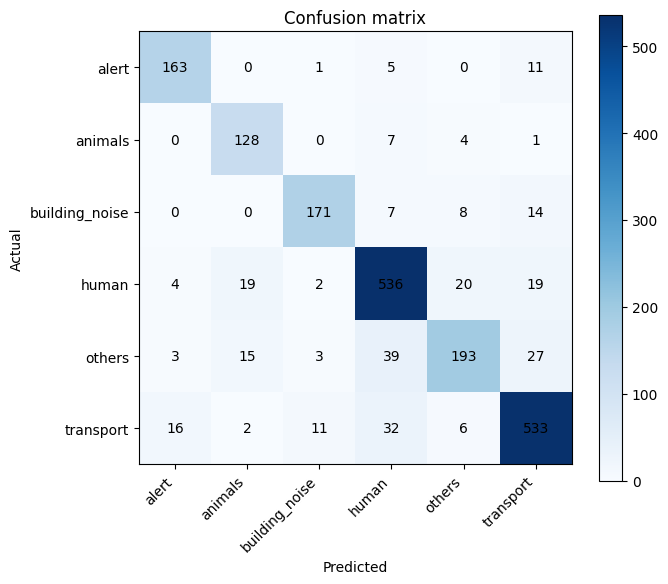

In [10]:
classes = sorted(y.unique())
cm = confusion_matrix(y_test, predictions, labels=classes)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
display(cm_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(col, row, cm[row, col], ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

## 11. Feature Importance

,feature,importance
1,numeric__longitude,0.358628
0,numeric__latitude,0.331833
2,numeric__month,0.071894
3,numeric__hour,0.040921
7,numeric__hour_cos,0.036291
4,numeric__day_of_week_num,0.035199
6,numeric__hour_sin,0.034125
8,numeric__dow_sin,0.033438
9,numeric__dow_cos,0.023741
10,categorical__period_daytime,0.011073


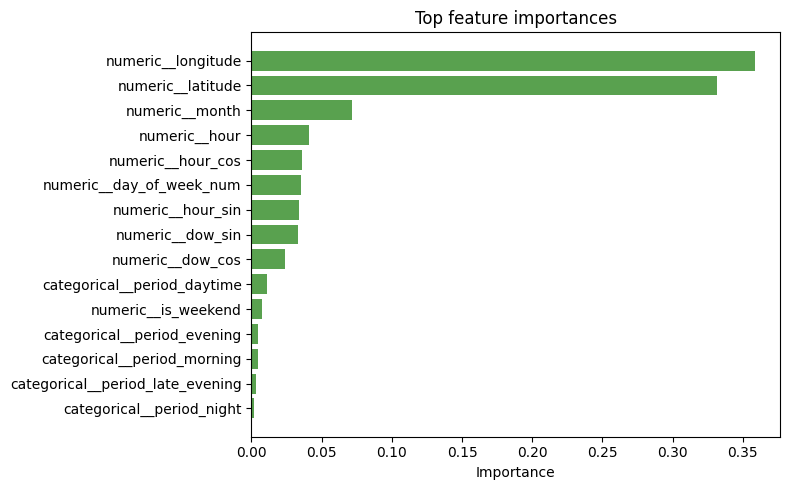

In [11]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#59A14F")
plt.title("Top feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 12. Save Model

In [12]:
ARTIFACTS_DIR.mkdir(exist_ok=True)

model_path = ARTIFACTS_DIR / "noise_source_classifier.joblib"
metadata_path = ARTIFACTS_DIR / "noise_source_classifier_metadata.json"

joblib.dump(model, model_path, compress=3)

model_metadata = {
    "created_at": datetime.now(timezone.utc).isoformat().replace("+00:00", "Z"),
    "dataset_path": str(DATA_PATH.relative_to(ROOT)),
    "target": TARGET,
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "classes": classes,
    "metrics": metrics,
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(model_metadata, file, ensure_ascii=False, indent=2)

print(f"Saved model: {model_path}")
print(f"Saved metadata: {metadata_path}")

Saved model: D:\Diploma\thesis-prediction-microservice\artifacts\noise_source_classifier.joblib
Saved metadata: D:\Diploma\thesis-prediction-microservice\artifacts\noise_source_classifier_metadata.json
